In [ ]:
# uv sync 同步 
# 可视化（最简单的散点图）

In [11]:
# 读取并构造 GeoDataFrame（放在一个单元格）
import zipfile
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from shapely import wkt
from pathlib import Path

zip_path = Path('../data/share/wgs84/csv_zip/bike_data_20210201_wgs84.zip')

with zipfile.ZipFile(zip_path) as z:
    with z.open(z.namelist()[0]) as f:
        df = pd.read_csv(f)

# 检查列名并构造经纬度列（容错）
if 'start_lng_wgs84' not in df.columns or 'start_lat_wgs84' not in df.columns:
    if 'start_geom_wgs84' in df.columns:
        pts = df['start_geom_wgs84'].map(lambda s: wkt.loads(s) if pd.notna(s) else None)
        df['start_lng_wgs84'] = pts.map(lambda p: p.x if p else None)
        df['start_lat_wgs84'] = pts.map(lambda p: p.y if p else None)

if 'end_lng_wgs84' not in df.columns or 'end_lat_wgs84' not in df.columns:
    if 'end_geom_wgs84' in df.columns:
        pts = df['end_geom_wgs84'].map(lambda s: wkt.loads(s) if pd.notna(s) else None)
        df['end_lng_wgs84'] = pts.map(lambda p: p.x if p else None)
        df['end_lat_wgs84'] = pts.map(lambda p: p.y if p else None)

# 构造起点/终点 GeoDataFrame（只包含有坐标的行）
start_df = df.dropna(subset=['start_lng_wgs84', 'start_lat_wgs84']).copy()
end_df = df.dropna(subset=['end_lng_wgs84', 'end_lat_wgs84']).copy()

gdf_start = gpd.GeoDataFrame(
    start_df,
    geometry=gpd.points_from_xy(start_df['start_lng_wgs84'], start_df['start_lat_wgs84']),
    crs="EPSG:4326"
)
gdf_end = gpd.GeoDataFrame(
    end_df,
    geometry=gpd.points_from_xy(end_df['end_lng_wgs84'], end_df['end_lat_wgs84']),
    crs="EPSG:4326"
)

# 合并用于统一绘图（添加类型标签）
gdf_start['point_type'] = 'start'
gdf_end['point_type'] = 'end'
gdf = gpd.GeoDataFrame(pd.concat([gdf_start, gdf_end], ignore_index=True), crs="EPSG:4326")

In [4]:
gdf_start.head()

,id,user_id,company_id,start_time_cn,end_time_cn,start_lng_wgs84,start_lat_wgs84,end_lng_wgs84,end_lat_wgs84,geometry,point_type
0,739280,f7e13f0f128d842ae423b7**********,0755**,2021-01-30 00:11:02,2021-01-30 02:45:06,114.057615,22.636642,114.064677,22.641817,POINT (114.05761 22.63664),start
1,225156,e4bb04101f92fe89873560**********,0755**,2021-01-30 00:11:02,2021-01-30 02:45:06,114.057527,22.636555,114.064589,22.641730,POINT (114.05753 22.63656),start
2,174552,3be57e758c67cb100c8a2f**********,0755**,2021-01-30 04:00:59,2021-01-30 04:23:26,114.251549,22.705693,114.251745,22.712045,POINT (114.25155 22.70569),start
3,43230,08ffd5dd9b259fe0f97c19**********,0755**,2021-01-30 05:04:31,2021-01-30 05:26:22,114.049196,22.537743,114.057103,22.521889,POINT (114.0492 22.53774),start
4,2349304,2b22acaddf313808a43620**********,0755**,2021-01-30 05:30:39,2021-01-30 05:52:14,114.013724,22.641506,114.007561,22.626346,POINT (114.01372 22.64151),start


<Axes: >

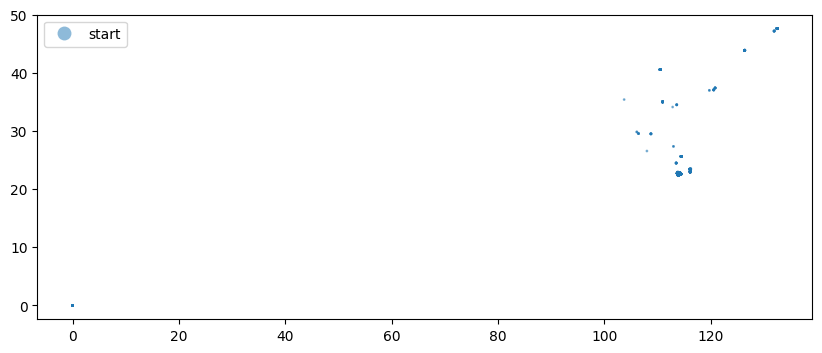

In [14]:
gdf_start.plot(column='point_type', figsize=(10, 10), alpha=0.5, markersize=1, legend=True)

In [12]:
# 转换时间为datetime
gdf_start['start_time_cn'] = pd.to_datetime(gdf_start['start_time_cn'])
gdf_end['end_time_cn'] = pd.to_datetime(gdf_end['end_time_cn'])


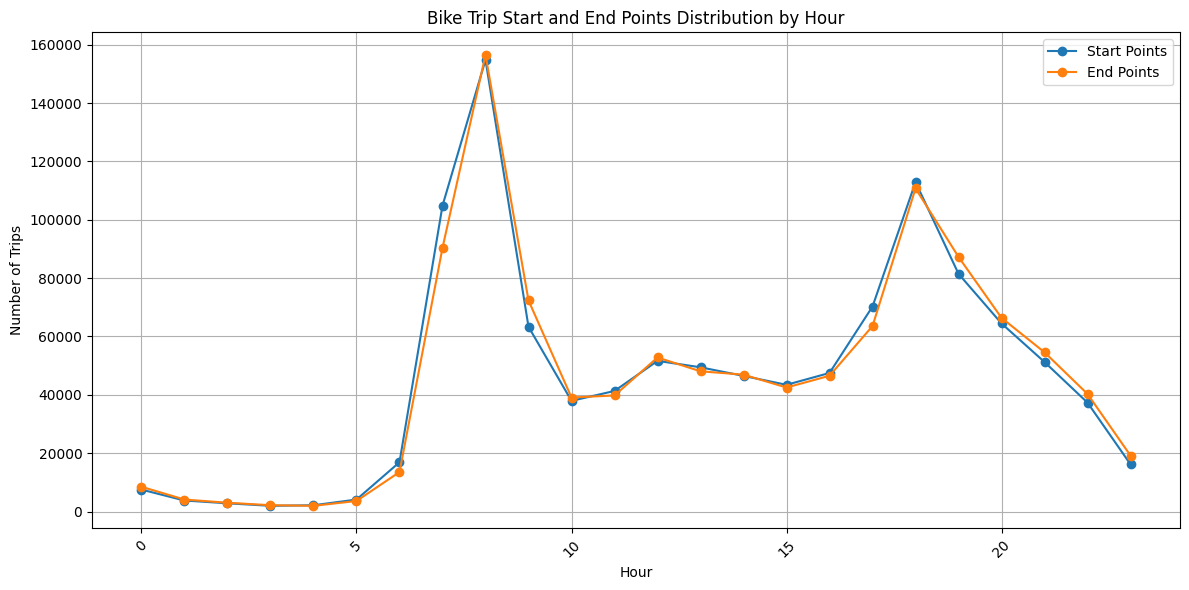

In [13]:
# 按照时间看分布
import matplotlib.pyplot as plt

# 按照时间分组统计起点和终点数量
start_counts = gdf_start.groupby(gdf_start['start_time_cn'].dt.hour).size()
end_counts = gdf_end.groupby(gdf_end['end_time_cn'].dt.hour).size()

# 绘制时间分布图
plt.figure(figsize=(12, 6))
plt.plot(start_counts.index, start_counts.values, label='Start Points', marker='o')
plt.plot(end_counts.index, end_counts.values, label='End Points', marker='o')
plt.title('Bike Trip Start and End Points Distribution by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()